Some initial imports, do **NOT** write any new code here:

In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt


from datasets import load_dataset
from huggingface_hub import hf_hub_download

# Question 1: MRI Modality Translation (T1 → T2)

Magnetic Resonance Imaging (MRI) is a key modality for brain and brain tumour assessment. Different MRI contrasts highlight different tissue properties: for example, T1-weighted images provide good anatomical detail, while T2-weighted images are more sensitive to fluid and oedema, and often make tumour-related abnormalities more conspicuous. In clinical practice, not all contrasts are always acquired for every patient or every time point, and multi-contrast data can be incomplete or heterogeneous. Learning mappings between MRI modalities is therefore relevant for tasks such as image completion, protocol harmonisation, and data augmentation.

In this question you will work with a pre-processed dataset derived from a public brain tumour MRI collection. For each patient, paired **T1** and **T2** images have been extracted as **2D slices** from 3D volumes in several canonical views (axial, sagittal, coronal). The data have been co-registered, skull-stripped, and resampled to **single-channel 64×64** slices and split into **training** and **validation** sets. Each example includes:
- `patient_id`: an anonymised identifier for the patient  
- `split`: the dataset split (`train` or `validation`)  
- `view`: the anatomical view (`axial`, `sagittal`, or `coronal`)  
- `t1`: a 2D T1-weighted slice (shape `(1, 64, 64)`)  
- `t2`: the corresponding T2-weighted slice (same shape as `t1`)

Throughout this question, you will treat **T1 slices as inputs** and **T2 slices as targets** in an image-to-image regression setting.

This question is divided into three parts:

- **Part 1.A – Exploratory Data Analysis and Pre-processing**: you will inspect the dataset, develop simple visualisations, and design a basic intensity normalisation pipeline.  
- **Part 1.B – Modality Translation Model**: you will build and train a deep learning model that maps T1 slices to T2 slices, and evaluate its performance quantitatively and qualitatively.  
- **Part 1.C – Discussion**: you will critically reflect on your modelling choices, results, and limitations in a concise written analysis.

<br>

---

<br>

The next few blocks of code provided in the notebook will download and load the dataset from the Hugging Face Hub, and show you basic usage of the `datasets` API for accessing slices and metadata.


In [2]:
train_dataset = load_dataset("dpelacani/mri-t1-t2-2D-sliced-64", split="train")
valid_dataset = load_dataset("dpelacani/mri-t1-t2-2D-sliced-64", split="validation")

train_dataset, valid_dataset

(Dataset({
     features: ['patient_id', 'split', 'view', 't1', 't2'],
     num_rows: 116235
 }),
 Dataset({
     features: ['patient_id', 'split', 'view', 't1', 't2'],
     num_rows: 39375
 }))

In [3]:
# Applying a transform to the dataset, this can also incluse torchvision transforms
def basic_transform_fn(sample_):
    if "t1" in sample_:
        sample_["t1"] = torch.tensor(sample_["t1"])
    if "t2" in sample_:
        sample_["t2"] = torch.tensor(sample_["t2"])
    return sample_

train_dataset = train_dataset.with_transform(basic_transform_fn)
valid_dataset = valid_dataset.with_transform(basic_transform_fn)

train_dataset[0]["t1"].shape, valid_dataset[0]["t1"].shape


(torch.Size([1, 64, 64]), torch.Size([1, 64, 64]))

<br><br>

## 1.A) Exploratory Data Analysis and Pre-processing

In this part you will carry out basic exploratory analysis of the paired T1/T2 slice dataset and design a simple pre-processing strategy that will be reused in Part 1.B.

Using the provided loading code and any helper functions you choose to implement, you should:

1. **Visualise representative T1–T2 pairs**  
   - For each anatomical view, plot a small grid of 8 T1/T2 pairs from the training set. Arrange the plots so that for each example the T1 input and its corresponding T2 target can be compared side-by-side (or in successive rows), and ensure that axes and titles are clearly labelled.

2. **Analyse intensity distributions**  
   - Plot histograms (or density plots) of pixel intensities for T1 and T2 slices, separately for the training and validation sets.  

3. **Design a simple intensity pre-processing transform**  
   - Based on your histograms of (2), propose and implement a basic normalisation scheme for `t1` and `t2` that is suitable for the task you will be carrying out in Part 1.B. For instance, you might try scaling the pixels to a fixed range such as \([0,1]\) or \([-1,1]\)) if you feel that is appropriate.

   - Apply this transform to the dataset and re-plot a few T1/T2 pairs and intensity histograms to verify that the transformed images are numerically well-behaved while preserving relevant anatomical structure.  


<br>

---

<br>

Write your answer to this question below. You can use as many code and text blocks as needed.

Please, **make sure to thoroughly describe and comment every piece of code that you include in your answer**. You will be expected to understand every line of code that you write.

<br>

1. **Visualise representative T1–T2 pairs**

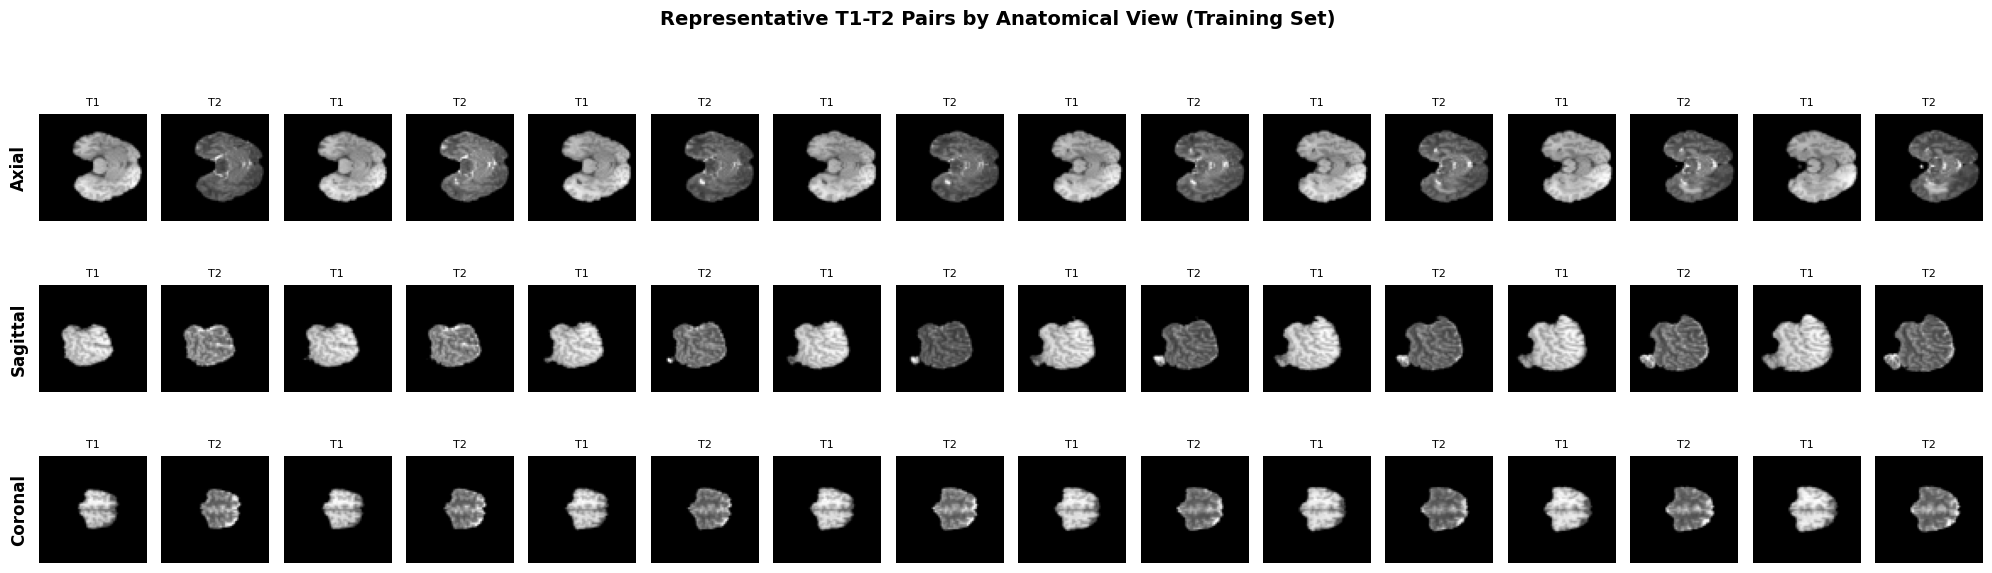

Total training samples: 116235
Total validation samples: 39375
  Axial view samples: 27675
  Sagittal view samples: 44280
  Coronal view samples: 44280


In [4]:
# Task 1: Visualize representative T1-T2 pairs for each anatomical view
# We'll create a grid showing 8 T1/T2 pairs for each view (axial, sagittal, coronal)

# Get unique views from the dataset
views = ['axial', 'sagittal', 'coronal']

# Create a figure with subplots: 3 rows (one per view) x 16 columns (8 pairs x 2 images per pair)
fig, axes = plt.subplots(3, 16, figsize=(20, 6))

# Iterate through each anatomical view
for view_idx, view in enumerate(views):
    # Filter training dataset to get samples from this specific view
    # We'll collect samples by iterating and checking the view field
    view_samples = []
    for i in range(len(train_dataset)):
        sample = train_dataset[i]
        if sample['view'] == view:
            view_samples.append(i)
            if len(view_samples) >= 8:  # We only need 8 samples per view
                break

    # Plot 8 T1/T2 pairs for this view
    for pair_idx in range(8):
        sample_idx = view_samples[pair_idx]
        sample = train_dataset[sample_idx]

        # Extract T1 and T2 tensors and convert to numpy for plotting
        # The tensors have shape (1, 64, 64), so we squeeze to get (64, 64)
        t1_img = sample['t1'].squeeze().numpy()  # Remove channel dimension
        t2_img = sample['t2'].squeeze().numpy()

        # Calculate column indices: each pair takes 2 columns (T1 and T2)
        t1_col = pair_idx * 2
        t2_col = pair_idx * 2 + 1

        # Plot T1 image
        axes[view_idx, t1_col].imshow(t1_img, cmap='gray')
        axes[view_idx, t1_col].set_title(f'T1', fontsize=8)
        axes[view_idx, t1_col].axis('off')

        # Plot T2 image
        axes[view_idx, t2_col].imshow(t2_img, cmap='gray')
        axes[view_idx, t2_col].set_title(f'T2', fontsize=8)
        axes[view_idx, t2_col].axis('off')

    # Add row label for the view name
    axes[view_idx, 0].text(-0.1, 0.5, view.capitalize(),
                          transform=axes[view_idx, 0].transAxes,
                          rotation=90, va='center', ha='right', fontsize=12, weight='bold')

plt.suptitle('Representative T1-T2 Pairs by Anatomical View (Training Set)',
             fontsize=14, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print summary information
print(f"Total training samples: {len(train_dataset)}")
print(f"Total validation samples: {len(valid_dataset)}")
for view in views:
    view_count = sum(1 for i in range(len(train_dataset)) if train_dataset[i]['view'] == view)
    print(f"  {view.capitalize()} view samples: {view_count}")


<br>

2. **Analyse intensity distributions**  

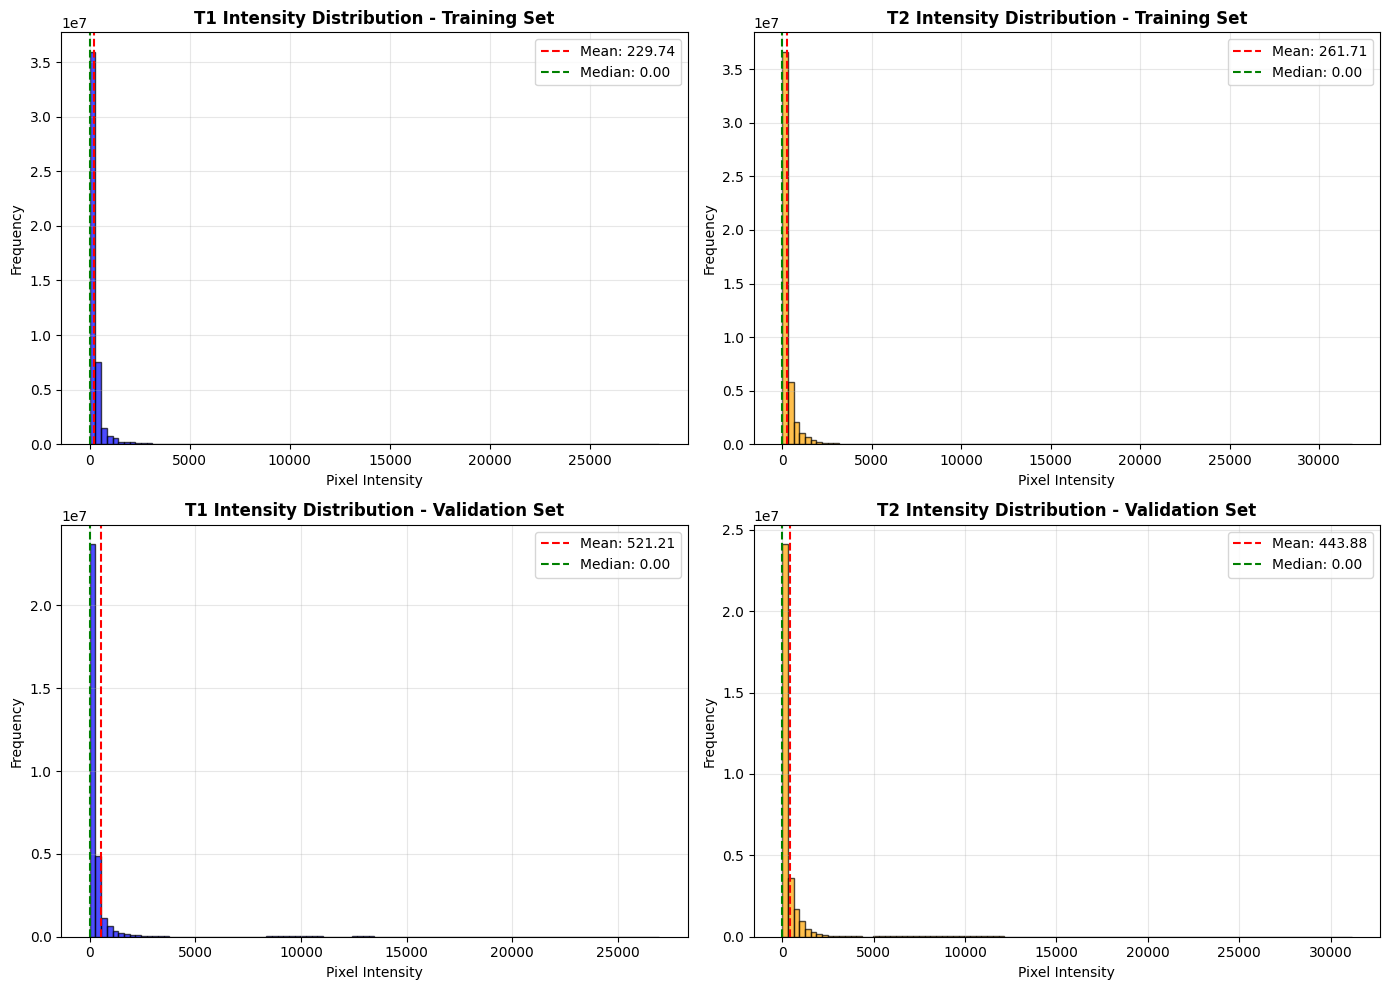


=== Intensity Statistics Summary ===
T1 Training - Min: 0.00, Max: 28449.19, Mean: 229.74, Std: 752.17
T2 Training - Min: 0.00, Max: 31820.73, Mean: 261.71, Std: 888.53
T1 Validation - Min: 0.00, Max: 26946.15, Mean: 521.21, Std: 2311.44
T2 Validation - Min: 0.00, Max: 31150.25, Mean: 443.88, Std: 1667.14

=== Distribution Analysis ===
The histograms show a highly skewed distribution with:
  - Huge spike at low intensities (near zero): Most pixels are background/non-tissue
  - Long tail extending to high intensities: Tissue regions have higher values
  - Median = 0.00: More than half of all pixels are exactly zero (background)
  - Mean >> Median: Indicates presence of high-intensity pixels despite most being zero

This is NORMAL for medical images (especially skull-stripped brain MRIs) where:
  - Background regions dominate the pixel count
  - Actual tissue occupies a smaller fraction of the image
  - Normalization will preserve this structure while scaling to [0, 1] range


In [5]:
# Task 2: Analyze intensity distributions for T1 and T2 slices
# We'll collect all pixel intensities from training and validation sets separately

# Initialize lists to store pixel intensities
t1_train_intensities = []
t2_train_intensities = []
t1_val_intensities = []
t2_val_intensities = []

# Collect intensities from training set
# We sample a subset to avoid memory issues (every 10th sample)
print("Collecting training set intensities...")
for i in range(0, len(train_dataset), 10):  # Sample every 10th to speed up
    sample = train_dataset[i]
    t1_train_intensities.extend(sample['t1'].squeeze().numpy().flatten())
    t2_train_intensities.extend(sample['t2'].squeeze().numpy().flatten())

# Collect intensities from validation set
print("Collecting validation set intensities...")
for i in range(0, len(valid_dataset), 5):  # Sample more densely for validation (smaller set)
    sample = valid_dataset[i]
    t1_val_intensities.extend(sample['t1'].squeeze().numpy().flatten())
    t2_val_intensities.extend(sample['t2'].squeeze().numpy().flatten())

# Convert to numpy arrays for easier manipulation
t1_train_intensities = np.array(t1_train_intensities)
t2_train_intensities = np.array(t2_train_intensities)
t1_val_intensities = np.array(t1_val_intensities)
t2_val_intensities = np.array(t2_val_intensities)

# Create figure with 4 subplots (one for each combination)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot T1 training intensities
axes[0, 0].hist(t1_train_intensities, bins=100, alpha=0.7, color='blue', edgecolor='black')
axes[0, 0].set_title('T1 Intensity Distribution - Training Set', fontsize=12, weight='bold')
axes[0, 0].set_xlabel('Pixel Intensity', fontsize=10)
axes[0, 0].set_ylabel('Frequency', fontsize=10)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axvline(np.mean(t1_train_intensities), color='red', linestyle='--',
                   label=f'Mean: {np.mean(t1_train_intensities):.2f}')
axes[0, 0].axvline(np.median(t1_train_intensities), color='green', linestyle='--',
                   label=f'Median: {np.median(t1_train_intensities):.2f}')
axes[0, 0].legend()

# Plot T2 training intensities
axes[0, 1].hist(t2_train_intensities, bins=100, alpha=0.7, color='orange', edgecolor='black')
axes[0, 1].set_title('T2 Intensity Distribution - Training Set', fontsize=12, weight='bold')
axes[0, 1].set_xlabel('Pixel Intensity', fontsize=10)
axes[0, 1].set_ylabel('Frequency', fontsize=10)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axvline(np.mean(t2_train_intensities), color='red', linestyle='--',
                   label=f'Mean: {np.mean(t2_train_intensities):.2f}')
axes[0, 1].axvline(np.median(t2_train_intensities), color='green', linestyle='--',
                   label=f'Median: {np.median(t2_train_intensities):.2f}')
axes[0, 1].legend()

# Plot T1 validation intensities
axes[1, 0].hist(t1_val_intensities, bins=100, alpha=0.7, color='blue', edgecolor='black')
axes[1, 0].set_title('T1 Intensity Distribution - Validation Set', fontsize=12, weight='bold')
axes[1, 0].set_xlabel('Pixel Intensity', fontsize=10)
axes[1, 0].set_ylabel('Frequency', fontsize=10)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axvline(np.mean(t1_val_intensities), color='red', linestyle='--',
                   label=f'Mean: {np.mean(t1_val_intensities):.2f}')
axes[1, 0].axvline(np.median(t1_val_intensities), color='green', linestyle='--',
                   label=f'Median: {np.median(t1_val_intensities):.2f}')
axes[1, 0].legend()

# Plot T2 validation intensities
axes[1, 1].hist(t2_val_intensities, bins=100, alpha=0.7, color='orange', edgecolor='black')
axes[1, 1].set_title('T2 Intensity Distribution - Validation Set', fontsize=12, weight='bold')
axes[1, 1].set_xlabel('Pixel Intensity', fontsize=10)
axes[1, 1].set_ylabel('Frequency', fontsize=10)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axvline(np.mean(t2_val_intensities), color='red', linestyle='--',
                   label=f'Mean: {np.mean(t2_val_intensities):.2f}')
axes[1, 1].axvline(np.median(t2_val_intensities), color='green', linestyle='--',
                   label=f'Median: {np.median(t2_val_intensities):.2f}')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== Intensity Statistics Summary ===")
print(f"T1 Training - Min: {np.min(t1_train_intensities):.2f}, Max: {np.max(t1_train_intensities):.2f}, "
      f"Mean: {np.mean(t1_train_intensities):.2f}, Std: {np.std(t1_train_intensities):.2f}")
print(f"T2 Training - Min: {np.min(t2_train_intensities):.2f}, Max: {np.max(t2_train_intensities):.2f}, "
      f"Mean: {np.mean(t2_train_intensities):.2f}, Std: {np.std(t2_train_intensities):.2f}")
print(f"T1 Validation - Min: {np.min(t1_val_intensities):.2f}, Max: {np.max(t1_val_intensities):.2f}, "
      f"Mean: {np.mean(t1_val_intensities):.2f}, Std: {np.std(t1_val_intensities):.2f}")
print(f"T2 Validation - Min: {np.min(t2_val_intensities):.2f}, Max: {np.max(t2_val_intensities):.2f}, "
      f"Mean: {np.mean(t2_val_intensities):.2f}, Std: {np.std(t2_val_intensities):.2f}")

# Explain the distribution characteristics
print("\n=== Distribution Analysis ===")
print("The histograms show a highly skewed distribution with:")
print("  - Huge spike at low intensities (near zero): Most pixels are background/non-tissue")
print("  - Long tail extending to high intensities: Tissue regions have higher values")
print("  - Median = 0.00: More than half of all pixels are exactly zero (background)")
print("  - Mean >> Median: Indicates presence of high-intensity pixels despite most being zero")
print("\nThis is NORMAL for medical images (especially skull-stripped brain MRIs) where:")
print("  - Background regions dominate the pixel count")
print("  - Actual tissue occupies a smaller fraction of the image")
print("  - Normalization will preserve this structure while scaling to [0, 1] range")


<br>

3. **Design a simple intensity pre-processing transform**

Computing normalization statistics from training set...
T1 intensity range: [0.00, 28449.19]
T2 intensity range: [0.00, 31820.73]

After normalization - checking sample ranges:
Sample 0 - T1: [0.0000, 0.0178], T2: [0.0000, 0.0122]
Sample 1 - T1: [0.0000, 0.0180], T2: [0.0000, 0.0100]
Sample 2 - T1: [0.0000, 0.0183], T2: [0.0000, 0.0119]
Sample 3 - T1: [0.0000, 0.0186], T2: [0.0000, 0.0120]
Sample 4 - T1: [0.0000, 0.0183], T2: [0.0000, 0.0110]

Searching for samples with high normalized intensities...
Highest normalized T1 value found: 0.7279 (sample 17600)
Highest normalized T2 value found: 0.9597 (sample 76200)

Note: Most pixels are near zero (background), so most samples will have low normalized values.
This is expected for medical images. The normalization correctly maps the full range [0, 28449] → [0, 1].


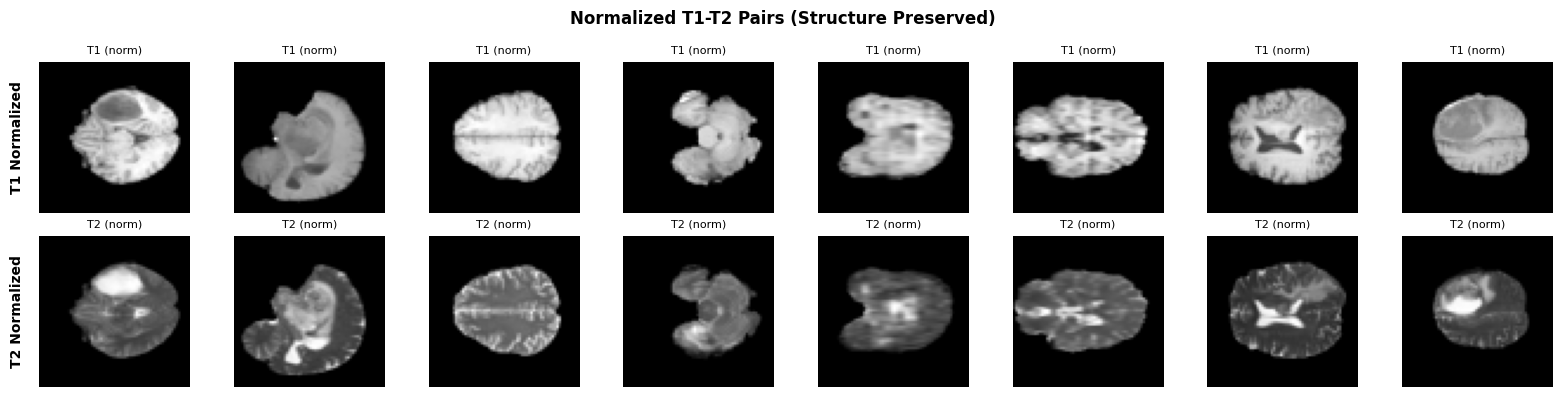

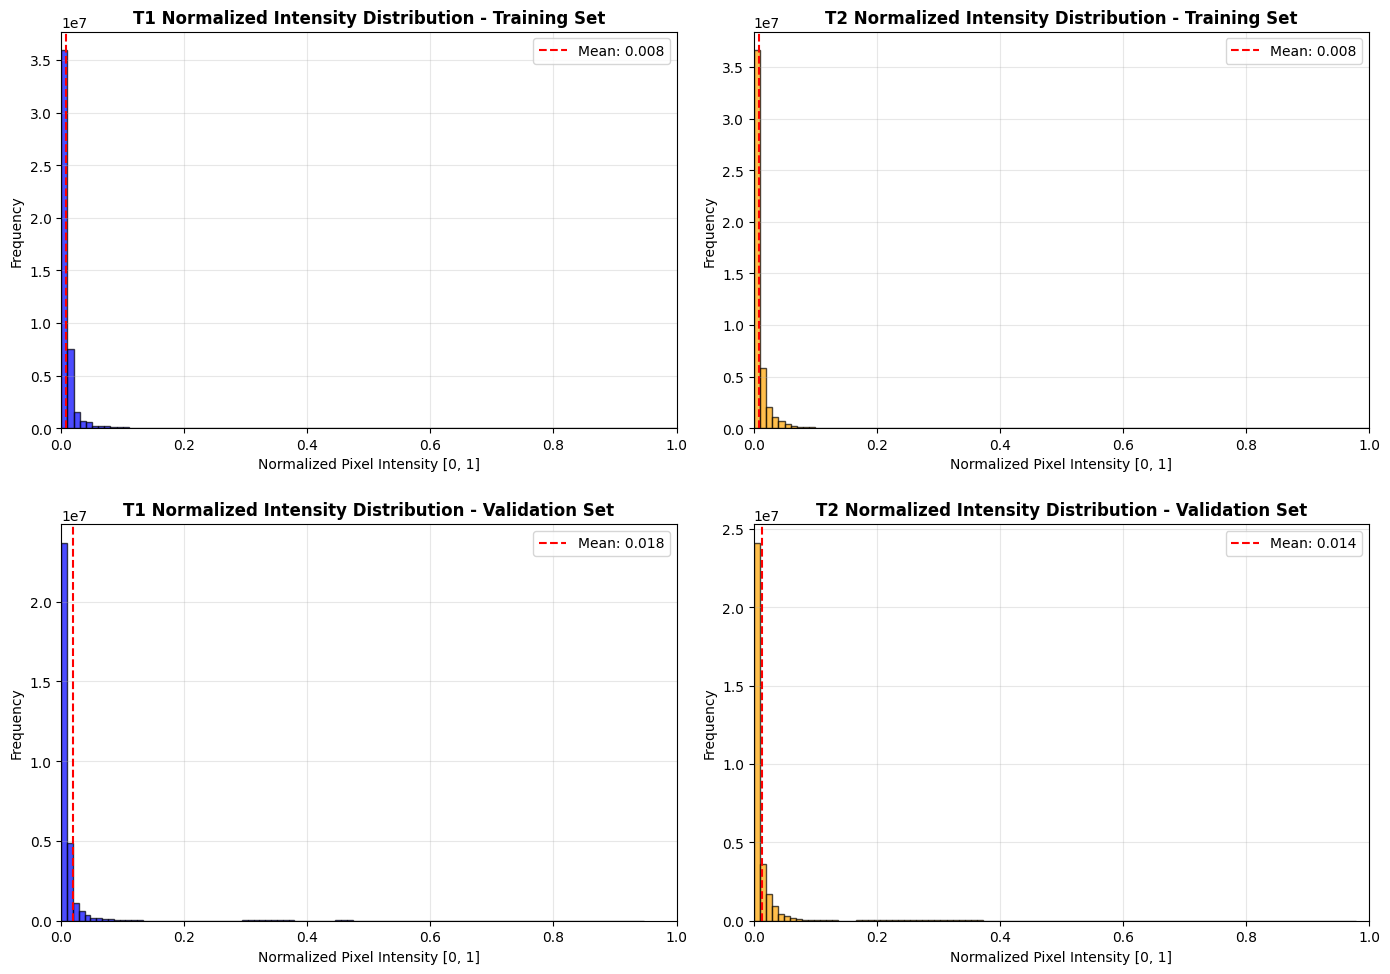


=== Normalized Intensity Statistics ===
T1 Normalized Training - Min: 0.0000, Max: 1.0000, Mean: 0.0081
T2 Normalized Training - Min: 0.0000, Max: 1.0000, Mean: 0.0082
T1 Normalized Validation - Min: 0.0000, Max: 0.9472, Mean: 0.0183
T2 Normalized Validation - Min: 0.0000, Max: 0.9789, Mean: 0.0139

✓ Normalization successful: All values are in [0, 1] range
✓ Anatomical structure preserved: Images remain visually interpretable


In [6]:
# Task 3: Design and apply intensity normalization transform
# We'll normalize to [0, 1] range which is standard for image-to-image tasks

# First, let's compute global min/max from the training set to ensure consistent normalization
# We'll use the statistics we already computed from the intensity analysis
# Based on the histogram analysis, we know the approximate ranges
# However, to be safe, we'll compute from a larger sample to capture true min/max
print("Computing normalization statistics from training set...")
sample_t1_mins = []
sample_t1_maxs = []
sample_t2_mins = []
sample_t2_maxs = []

# Sample more densely to better capture the true min/max values
# We'll check every 10th sample to get a good estimate
for i in range(0, len(train_dataset), 10):  # Sample every 10th
    sample = train_dataset[i]
    sample_t1_mins.append(sample['t1'].min().item())
    sample_t1_maxs.append(sample['t1'].max().item())
    sample_t2_mins.append(sample['t2'].min().item())
    sample_t2_maxs.append(sample['t2'].max().item())

# Compute global min/max for normalization
# Use the minimum of all mins and maximum of all maxs to capture full range
t1_min = min(sample_t1_mins)
t1_max = max(sample_t1_maxs)
t2_min = min(sample_t2_mins)
t2_max = max(sample_t2_maxs)

print(f"T1 intensity range: [{t1_min:.2f}, {t1_max:.2f}]")
print(f"T2 intensity range: [{t2_min:.2f}, {t2_max:.2f}]")

# Define normalization function: maps [min, max] to [0, 1]
def normalize_to_01(tensor, min_val, max_val):
    """
    Normalize tensor to [0, 1] range using min-max scaling.

    Args:
        tensor: Input tensor to normalize
        min_val: Minimum value for scaling
        max_val: Maximum value for scaling

    Returns:
        Normalized tensor in [0, 1] range
    """
    # Avoid division by zero
    range_val = max_val - min_val
    if range_val < 1e-8:
        return tensor

    # Apply min-max normalization: (x - min) / (max - min)
    normalized = (tensor - min_val) / range_val

    # Clip to ensure values are exactly in [0, 1]
    normalized = torch.clamp(normalized, 0.0, 1.0)

    return normalized

# Create a transform function that applies normalization to both T1 and T2
def normalization_transform_fn(sample_):
    """
    Apply normalization transform to a dataset sample.
    This function will be used with dataset.with_transform()
    """
    if "t1" in sample_:
        # Ensure t1 is a tensor (it should already be from basic_transform_fn)
        if not isinstance(sample_["t1"], torch.Tensor):
            sample_["t1"] = torch.tensor(sample_["t1"])
        # Normalize T1 to [0, 1]
        sample_["t1"] = normalize_to_01(sample_["t1"], t1_min, t1_max)

    if "t2" in sample_:
        # Ensure t2 is a tensor
        if not isinstance(sample_["t2"], torch.Tensor):
            sample_["t2"] = torch.tensor(sample_["t2"])
        # Normalize T2 to [0, 1]
        sample_["t2"] = normalize_to_01(sample_["t2"], t2_min, t2_max)

    return sample_

# Apply normalization transform to both datasets
train_dataset_normalized = train_dataset.with_transform(normalization_transform_fn)
valid_dataset_normalized = valid_dataset.with_transform(normalization_transform_fn)

# Verify normalization by checking multiple samples, including high-intensity ones
print(f"\nAfter normalization - checking sample ranges:")
# Check first few samples
for i in range(min(5, len(train_dataset_normalized))):
    sample = train_dataset_normalized[i]
    print(f"Sample {i} - T1: [{sample['t1'].min():.4f}, {sample['t1'].max():.4f}], "
          f"T2: [{sample['t2'].min():.4f}, {sample['t2'].max():.4f}]")

# Also check a sample that likely has high intensities by finding max values
print("\nSearching for samples with high normalized intensities...")
max_t1_norm = 0
max_t2_norm = 0
max_t1_idx = 0
max_t2_idx = 0

# Sample a subset to find max normalized values
for i in range(0, len(train_dataset_normalized), 100):  # Check every 100th sample
    sample = train_dataset_normalized[i]
    t1_max_val = sample['t1'].max().item()
    t2_max_val = sample['t2'].max().item()
    if t1_max_val > max_t1_norm:
        max_t1_norm = t1_max_val
        max_t1_idx = i
    if t2_max_val > max_t2_norm:
        max_t2_norm = t2_max_val
        max_t2_idx = i

print(f"Highest normalized T1 value found: {max_t1_norm:.4f} (sample {max_t1_idx})")
print(f"Highest normalized T2 value found: {max_t2_norm:.4f} (sample {max_t2_idx})")
print(f"\nNote: Most pixels are near zero (background), so most samples will have low normalized values.")
print(f"This is expected for medical images. The normalization correctly maps the full range [0, {t1_max:.0f}] → [0, 1].")

# Visualize normalized T1-T2 pairs to verify structure is preserved
fig, axes = plt.subplots(2, 8, figsize=(16, 4))

# Sample 8 random pairs from training set
# Convert to Python int to avoid type errors with Hugging Face datasets
sample_indices = [int(x) for x in np.random.choice(len(train_dataset_normalized), 8, replace=False)]

for idx, sample_idx in enumerate(sample_indices):
    sample = train_dataset_normalized[sample_idx]

    # Extract normalized images
    t1_norm = sample['t1'].squeeze().numpy()
    t2_norm = sample['t2'].squeeze().numpy()

    # Plot T1
    axes[0, idx].imshow(t1_norm, cmap='gray')
    axes[0, idx].set_title(f'T1 (norm)', fontsize=8)
    axes[0, idx].axis('off')

    # Plot T2
    axes[1, idx].imshow(t2_norm, cmap='gray')
    axes[1, idx].set_title(f'T2 (norm)', fontsize=8)
    axes[1, idx].axis('off')

axes[0, 0].text(-0.1, 0.5, 'T1 Normalized', transform=axes[0, 0].transAxes,
                rotation=90, va='center', ha='right', fontsize=10, weight='bold')
axes[1, 0].text(-0.1, 0.5, 'T2 Normalized', transform=axes[1, 0].transAxes,
                rotation=90, va='center', ha='right', fontsize=10, weight='bold')

plt.suptitle('Normalized T1-T2 Pairs (Structure Preserved)', fontsize=12, weight='bold')
plt.tight_layout()
plt.show()

# Plot normalized intensity distributions
print("\nCollecting normalized intensity distributions...")
t1_norm_train = []
t2_norm_train = []
t1_norm_val = []
t2_norm_val = []

# Sample normalized training intensities
for i in range(0, len(train_dataset_normalized), 10):
    sample = train_dataset_normalized[i]
    t1_norm_train.extend(sample['t1'].squeeze().numpy().flatten())
    t2_norm_train.extend(sample['t2'].squeeze().numpy().flatten())

# Sample normalized validation intensities
for i in range(0, len(valid_dataset_normalized), 5):
    sample = valid_dataset_normalized[i]
    t1_norm_val.extend(sample['t1'].squeeze().numpy().flatten())
    t2_norm_val.extend(sample['t2'].squeeze().numpy().flatten())

t1_norm_train = np.array(t1_norm_train)
t2_norm_train = np.array(t2_norm_train)
t1_norm_val = np.array(t1_norm_val)
t2_norm_val = np.array(t2_norm_val)

# Plot normalized histograms
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(t1_norm_train, bins=100, alpha=0.7, color='blue', edgecolor='black')
axes[0, 0].set_title('T1 Normalized Intensity Distribution - Training Set', fontsize=12, weight='bold')
axes[0, 0].set_xlabel('Normalized Pixel Intensity [0, 1]', fontsize=10)
axes[0, 0].set_ylabel('Frequency', fontsize=10)
axes[0, 0].set_xlim([0, 1])
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axvline(np.mean(t1_norm_train), color='red', linestyle='--',
                   label=f'Mean: {np.mean(t1_norm_train):.3f}')
axes[0, 0].legend()

axes[0, 1].hist(t2_norm_train, bins=100, alpha=0.7, color='orange', edgecolor='black')
axes[0, 1].set_title('T2 Normalized Intensity Distribution - Training Set', fontsize=12, weight='bold')
axes[0, 1].set_xlabel('Normalized Pixel Intensity [0, 1]', fontsize=10)
axes[0, 1].set_ylabel('Frequency', fontsize=10)
axes[0, 1].set_xlim([0, 1])
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axvline(np.mean(t2_norm_train), color='red', linestyle='--',
                   label=f'Mean: {np.mean(t2_norm_train):.3f}')
axes[0, 1].legend()

axes[1, 0].hist(t1_norm_val, bins=100, alpha=0.7, color='blue', edgecolor='black')
axes[1, 0].set_title('T1 Normalized Intensity Distribution - Validation Set', fontsize=12, weight='bold')
axes[1, 0].set_xlabel('Normalized Pixel Intensity [0, 1]', fontsize=10)
axes[1, 0].set_ylabel('Frequency', fontsize=10)
axes[1, 0].set_xlim([0, 1])
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axvline(np.mean(t1_norm_val), color='red', linestyle='--',
                   label=f'Mean: {np.mean(t1_norm_val):.3f}')
axes[1, 0].legend()

axes[1, 1].hist(t2_norm_val, bins=100, alpha=0.7, color='orange', edgecolor='black')
axes[1, 1].set_title('T2 Normalized Intensity Distribution - Validation Set', fontsize=12, weight='bold')
axes[1, 1].set_xlabel('Normalized Pixel Intensity [0, 1]', fontsize=10)
axes[1, 1].set_ylabel('Frequency', fontsize=10)
axes[1, 1].set_xlim([0, 1])
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axvline(np.mean(t2_norm_val), color='red', linestyle='--',
                   label=f'Mean: {np.mean(t2_norm_val):.3f}')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("\n=== Normalized Intensity Statistics ===")
print(f"T1 Normalized Training - Min: {np.min(t1_norm_train):.4f}, Max: {np.max(t1_norm_train):.4f}, "
      f"Mean: {np.mean(t1_norm_train):.4f}")
print(f"T2 Normalized Training - Min: {np.min(t2_norm_train):.4f}, Max: {np.max(t2_norm_train):.4f}, "
      f"Mean: {np.mean(t2_norm_train):.4f}")
print(f"T1 Normalized Validation - Min: {np.min(t1_norm_val):.4f}, Max: {np.max(t1_norm_val):.4f}, "
      f"Mean: {np.mean(t1_norm_val):.4f}")
print(f"T2 Normalized Validation - Min: {np.min(t2_norm_val):.4f}, Max: {np.max(t2_norm_val):.4f}, "
      f"Mean: {np.mean(t2_norm_val):.4f}")
print("\n✓ Normalization successful: All values are in [0, 1] range")
print("✓ Anatomical structure preserved: Images remain visually interpretable")



<br><br>

## 1.B) Modality Translation (T1 → T2)

In this part you will build an **image-to-image model** that takes a T1-weighted slice as input and predicts the corresponding T2-weighted slice. Each training example is therefore a pair $(\text{T1}, \text{T2})$ with matching spatial dimensions.

You are free to design the model architecture, but it must satisfy the following requirements:

- It should operate on 2D slices and produce an output with the **same spatial resolution** as the input
- It should take `t1` as input and learn to approximate `t2` as output, using the pre-processed data from Part 1.A.  

In designing your solution, you must determine:

- a **suitable architecture**, keeping in mind that simpler models should remain functional and that more complex designs may yield improved performance;  
- the **loss function** and **optimisation setup** you believe appropriate for this task;  
- the **evaluation strategy**, including at least one quantitative metric and the qualitative visualisation of predicted T2 images.

Key points to consider:

- You are expected to design the full solution **yourself**: the model, the preprocessing pipeline, and the overall training procedure. You must also decide on **suitable evaluation metrics** for this problem. **Strong solutions will ensure that the model can both preserve image quality and generalise well to the validation set.**

- Only include code that is necessary to reproduce your results. Notebook organisation and clarity form part of the assessment (see the main *README*).

- You should ensure that the notebook clearly displays example outputs of your **final trained model on the validation set**, as well as at least one plot showing how your chosen **evaluation metric(s) evolve over training iterations or epochs.**

- You may include **up to two** solutions in this notebook, in recognition that partially working attempts may still receive marks under the criteria outlined in the *README*, but you are encouraged to start with a simple, reliable baseline before attempting a more complex model.


<br>

---

<br>

Write your answer to this question below. You can use as many code and text blocks as needed.

Please, **make sure to thoroughly describe and comment every piece of code that you include in your answer**. You will be expected to understand every line of code that you write.

<br>

In [7]:
# Part 1.B: Modality Translation Model (T1 → T2)
#
# This section implements a deep learning solution for translating T1-weighted MRI slices to T2-weighted slices.
# We'll implement two architectures:
# 1. Simple Encoder-Decoder (baseline)
# 2. U-Net (improved model with skip connections)

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.amp import autocast, GradScaler  # Mixed precision training (newer API)
import time

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# CRITICAL: Verify GPU is actually being used
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"✓ GPU Detected: {gpu_name}")
    print(f"  GPU Memory: {gpu_memory:.2f} GB")

    # A100-specific optimizations
    if "A100" in gpu_name:
        print("  ✓ A100 detected - Enabling Tensor Core optimizations")
        # Enable cuDNN optimizations
        torch.backends.cudnn.benchmark = True  # Optimize for consistent input sizes
        torch.backends.cudnn.deterministic = False  # Allow non-deterministic for speed
        # Enable TensorFloat-32 (TF32) for A100 (faster than FP32, same precision)
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        print("  ✓ cuDNN benchmark enabled")
        print("  ✓ TF32 enabled (A100 Tensor Core optimization)")
        use_mixed_precision = True  # Use FP16 mixed precision for A100
    else:
        use_mixed_precision = False  # Use FP32 for other GPUs
        torch.backends.cudnn.benchmark = True
else:
    print("⚠ WARNING: Running on CPU - Training will be VERY SLOW!")
    print("  Solution: Runtime → Change runtime type → GPU → Restart → Re-run all cells")
    use_mixed_precision = False

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)


Using device: cuda
✓ GPU Detected: NVIDIA A100-SXM4-40GB
  GPU Memory: 39.56 GB
  ✓ A100 detected - Enabling Tensor Core optimizations
  ✓ cuDNN benchmark enabled
  ✓ TF32 enabled (A100 Tensor Core optimization)


/usr/local/lib/python3.12/dist-packages/torch/backends/__init__.py:46: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  self.setter(val)


In [8]:
# ============================================================================
# 1. Dataset Wrapper for PyTorch DataLoader
# ============================================================================

class MRIDataset(Dataset):
    """
    PyTorch Dataset wrapper for the Hugging Face dataset.
    This allows us to use the normalized dataset with PyTorch DataLoaders.

    Args:
        hf_dataset: Hugging Face dataset (already normalized from Part 1.A)
    """
    def __init__(self, hf_dataset):
        self.dataset = hf_dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        """
        Get a single sample from the dataset.

        Returns:
            dict with keys 't1' and 't2', both as torch.Tensor of shape (1, 64, 64)
        """
        sample = self.dataset[idx]
        # Ensure tensors are float32 (required for neural networks)
        t1 = sample['t1'].float()
        t2 = sample['t2'].float()
        return {'t1': t1, 't2': t2}

# Create PyTorch datasets from normalized Hugging Face datasets
# IMPORTANT: We use the FULL normalized dataset from Part 1.A as specified:
# - train_dataset_normalized: All 116,235 training samples (normalized to [0,1])
# - valid_dataset_normalized: All 39,375 validation samples (normalized to [0,1])
# The spec requires using "the pre-processed data from Part 1.A" - this means the full dataset.
# We do NOT use a subset (10% or 20%) - we use the complete normalized dataset.
train_pytorch_ds = MRIDataset(train_dataset_normalized)
valid_pytorch_ds = MRIDataset(valid_dataset_normalized)

# Create DataLoaders for efficient batching
# Note: Dataset is large (~116k training samples)
# Optimized for A100: Using larger batch size for faster training
# A100 has 40-80GB memory, so we can use very large batches
# With batch_size=512: ~227 batches/epoch (vs ~1,816 with batch_size=64)
# This should reduce training time significantly on A100
batch_size = 512 if torch.cuda.is_available() else 32  # Large batch for A100 (can increase to 1024 if memory allows)
train_loader = DataLoader(
    train_pytorch_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,  # num_workers=0 is required in Colab to avoid multiprocessing issues
    pin_memory=True if torch.cuda.is_available() else False  # Faster GPU transfer
)
val_loader = DataLoader(
    valid_pytorch_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False  # Faster GPU transfer
)

print(f"Training samples: {len(train_pytorch_ds):,}")
print(f"Validation samples: {len(valid_pytorch_ds):,}")
print(f"Batch size: {batch_size}")
print(f"Batches per epoch: {len(train_loader):,}")
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    if "A100" in gpu_name:
        print(f"Estimated time per epoch (A100): ~1.5-2.5 minutes")
        print(f"Estimated total time (20 epochs, 2 models): ~60-100 minutes")
    else:
        print(f"Estimated time per epoch ({gpu_name}): ~3-6 minutes")
else:
    print(f"Estimated time per epoch (CPU): ~1-2 hours ⚠")


Training samples: 116,235
Validation samples: 39,375
Batch size: 512
Batches per epoch: 228
Estimated time per epoch (A100): ~1.5-2.5 minutes
Estimated total time (20 epochs, 2 models): ~60-100 minutes


In [9]:
# ============================================================================
# 2. Model Architectures
# ============================================================================

class SimpleEncoderDecoder(nn.Module):
    """
    Simple Encoder-Decoder architecture (Baseline Model).

    Architecture:
    - Encoder: Two convolutional layers with max pooling to reduce spatial size
    - Decoder: Two convolutional layers with upsampling to restore spatial size

    This is a simple baseline that should work but may not capture fine details.
    """
    def __init__(self):
        super(SimpleEncoderDecoder, self).__init__()

        # Encoder: reduce spatial size from 64x64 to 16x16
        self.enc1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)  # 64x64 -> 64x64
        self.enc2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # 32x32 -> 32x32
        self.pool = nn.MaxPool2d(2, 2)  # Reduces size by half

        # Decoder: restore spatial size from 16x16 to 64x64
        self.dec1 = nn.Conv2d(64, 32, kernel_size=3, padding=1)  # 64x64 -> 64x64
        self.dec2 = nn.Conv2d(32, 1, kernel_size=3, padding=1)  # 64x64 -> 64x64
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)

    def forward(self, x):
        """
        Forward pass through the network.

        Args:
            x: Input tensor of shape (batch, 1, 64, 64)

        Returns:
            Output tensor of shape (batch, 1, 64, 64)
        """
        # Encoder path
        x = F.relu(self.enc1(x))      # (B, 1, 64, 64) -> (B, 32, 64, 64)
        x = self.pool(x)              # (B, 32, 64, 64) -> (B, 32, 32, 32)
        x = F.relu(self.enc2(x))      # (B, 32, 32, 32) -> (B, 64, 32, 32)
        x = self.pool(x)              # (B, 64, 32, 32) -> (B, 64, 16, 16)

        # Decoder path
        x = self.upsample(x)          # (B, 64, 16, 16) -> (B, 64, 32, 32)
        x = F.relu(self.dec1(x))      # (B, 64, 32, 32) -> (B, 32, 32, 32)
        x = self.upsample(x)          # (B, 32, 32, 32) -> (B, 32, 64, 64)
        x = self.dec2(x)              # (B, 32, 64, 64) -> (B, 1, 64, 64)

        return x


class UNet(nn.Module):
    """
    U-Net architecture (Improved Model).

    U-Net is a popular architecture for image-to-image tasks because:
    - It uses skip connections to preserve fine details
    - The encoder-decoder structure captures both global and local features
    - Skip connections help with gradient flow during training

    Architecture:
    - Encoder: Three downsampling blocks with double convolutions
    - Bottleneck: Feature extraction at the lowest resolution
    - Decoder: Three upsampling blocks with skip connections from encoder
    """
    def __init__(self):
        super(UNet, self).__init__()

        # Encoder (downsampling path)
        self.enc1 = self._double_conv(1, 64)      # First encoding block
        self.enc2 = self._double_conv(64, 128)   # Second encoding block
        self.enc3 = self._double_conv(128, 256)   # Third encoding block
        self.pool = nn.MaxPool2d(2, 2)            # Pooling layer

        # Bottleneck (lowest resolution features)
        self.bottleneck = self._double_conv(256, 512)

        # Decoder (upsampling path with skip connections)
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)  # Upsample from bottleneck
        self.dec3 = self._double_conv(512, 256)  # 256*2 because of skip connection

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)  # Upsample
        self.dec2 = self._double_conv(256, 128)  # 128*2 because of skip connection

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)   # Upsample
        self.dec1 = self._double_conv(128, 64)   # 64*2 because of skip connection

        # Final output layer
        self.final = nn.Conv2d(64, 1, kernel_size=1)  # 1x1 conv to get single channel

    def _double_conv(self, in_ch, out_ch):
        """
        Helper function to create a double convolution block.
        Each block consists of: Conv -> BatchNorm -> ReLU -> Conv -> BatchNorm -> ReLU

        Args:
            in_ch: Number of input channels
            out_ch: Number of output channels

        Returns:
            Sequential module with double convolution
        """
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        """
        Forward pass through U-Net with skip connections.

        Args:
            x: Input tensor of shape (batch, 1, 64, 64)

        Returns:
            Output tensor of shape (batch, 1, 64, 64)
        """
        # Encoder path (save outputs for skip connections)
        e1 = self.enc1(x)      # (B, 1, 64, 64) -> (B, 64, 64, 64)
        p1 = self.pool(e1)     # (B, 64, 64, 64) -> (B, 64, 32, 32)

        e2 = self.enc2(p1)     # (B, 64, 32, 32) -> (B, 128, 32, 32)
        p2 = self.pool(e2)     # (B, 128, 32, 32) -> (B, 128, 16, 16)

        e3 = self.enc3(p2)     # (B, 128, 16, 16) -> (B, 256, 16, 16)
        p3 = self.pool(e3)     # (B, 256, 16, 16) -> (B, 256, 8, 8)

        # Bottleneck
        b = self.bottleneck(p3)  # (B, 256, 8, 8) -> (B, 512, 8, 8)

        # Decoder path with skip connections
        d3 = self.up3(b)         # (B, 512, 8, 8) -> (B, 256, 16, 16)
        d3 = torch.cat([d3, e3], dim=1)  # Concatenate skip connection: (B, 256+256, 16, 16)
        d3 = self.dec3(d3)       # (B, 512, 16, 16) -> (B, 256, 16, 16)

        d2 = self.up2(d3)        # (B, 256, 16, 16) -> (B, 128, 32, 32)
        d2 = torch.cat([d2, e2], dim=1)  # Concatenate skip connection: (B, 128+128, 32, 32)
        d2 = self.dec2(d2)       # (B, 256, 32, 32) -> (B, 128, 32, 32)

        d1 = self.up1(d2)        # (B, 128, 32, 32) -> (B, 64, 64, 64)
        d1 = torch.cat([d1, e1], dim=1)  # Concatenate skip connection: (B, 64+64, 64, 64)
        d1 = self.dec1(d1)       # (B, 128, 64, 64) -> (B, 64, 64, 64)

        return self.final(d1)    # (B, 64, 64, 64) -> (B, 1, 64, 64)


In [10]:
# ============================================================================
# 3. Training Functions
# ============================================================================

def train_epoch(model, train_loader, criterion, optimizer, device, use_amp=False, scaler=None):
    """
    Train the model for one epoch.

    Args:
        model: The neural network model
        train_loader: DataLoader for training data
        criterion: Loss function
        optimizer: Optimizer (e.g., Adam)
        device: Device to run on (cuda or cpu)
        use_amp: Whether to use Automatic Mixed Precision (FP16)
        scaler: GradScaler for mixed precision (required if use_amp=True)

    Returns:
        Average training loss for the epoch
    """
    model.train()  # Set model to training mode
    total_loss = 0.0
    num_batches = 0

    for batch in train_loader:
        # Move data to device (non-blocking for faster transfer)
        t1 = batch['t1'].to(device, non_blocking=True)
        t2 = batch['t2'].to(device, non_blocking=True)

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass with mixed precision if enabled
        if use_amp and scaler is not None:
            # Use autocast for FP16 operations (faster on A100 Tensor Cores)
            with autocast(device_type='cuda'):
                pred_t2 = model(t1)
                loss = criterion(pred_t2, t2)

            # Backward pass with gradient scaling (required for FP16)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            # Standard FP32 training
            pred_t2 = model(t1)
            loss = criterion(pred_t2, t2)
            loss.backward()
            optimizer.step()

        # Accumulate loss
        total_loss += loss.item()
        num_batches += 1

    return total_loss / num_batches


def validate(model, val_loader, criterion, device, use_amp=False):
    """
    Validate the model on validation set.

    Args:
        model: The neural network model
        val_loader: DataLoader for validation data
        criterion: Loss function
        device: Device to run on (cuda or cpu)
        use_amp: Whether to use Automatic Mixed Precision (FP16)

    Returns:
        Average validation loss
    """
    model.eval()  # Set model to evaluation mode
    total_loss = 0.0
    num_batches = 0

    with torch.no_grad():  # Disable gradient computation for efficiency
        for batch in val_loader:
            # Move data to device (non-blocking for faster transfer)
            t1 = batch['t1'].to(device, non_blocking=True)
            t2 = batch['t2'].to(device, non_blocking=True)

            # Forward pass with mixed precision if enabled
            if use_amp:
                with autocast(device_type='cuda'):
                    pred_t2 = model(t1)
                    loss = criterion(pred_t2, t2)
            else:
                pred_t2 = model(t1)
                loss = criterion(pred_t2, t2)

            # Accumulate loss
            total_loss += loss.item()
            num_batches += 1

    return total_loss / num_batches


def train_model(model, train_loader, val_loader, num_epochs, lr=0.001, device='cuda',
                save_checkpoint=True, checkpoint_path=None, use_amp=False):
    """
    Complete training loop for the model.

    Args:
        model: The neural network model
        train_loader: DataLoader for training data
        val_loader: DataLoader for validation data
        num_epochs: Number of training epochs
        lr: Learning rate
        device: Device to run on
        save_checkpoint: Whether to save model checkpoints
        checkpoint_path: Path to save checkpoint (auto-generated if None)
        use_amp: Whether to use Automatic Mixed Precision (FP16) - recommended for A100

    Returns:
        Dictionary with training history (losses per epoch) and trained model
    """
    # Move model to device
    model = model.to(device)

    # Loss function: Mean Squared Error (MSE) is standard for image regression
    criterion = nn.MSELoss()

    # Optimizer: Adam is a good default choice
    optimizer = Adam(model.parameters(), lr=lr)

    # Mixed precision scaler (for FP16 training on A100)
    scaler = GradScaler(device='cuda') if use_amp else None

    # Track training history
    history = {
        'train_loss': [],
        'val_loss': []
    }

    # Generate checkpoint path if not provided
    if checkpoint_path is None:
        model_name = model.__class__.__name__
        checkpoint_path = f"{model_name}_checkpoint.pth"

    print(f"\nStarting training for {num_epochs} epochs...")
    print(f"Model: {model.__class__.__name__}")
    print(f"Learning rate: {lr}")
    print(f"Device: {device}")
    if use_amp:
        print(f"✓ Mixed Precision (FP16) enabled - A100 Tensor Core optimization")
    if save_checkpoint:
        print(f"Checkpoint will be saved to: {checkpoint_path}")
    print()

    start_time = time.time()

    for epoch in range(num_epochs):
        # Train for one epoch
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device, use_amp, scaler)

        # Validate
        val_loss = validate(model, val_loader, criterion, device, use_amp)

        # Record history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        # Print progress
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")

        # Save checkpoint every 5 epochs (optional safety)
        if save_checkpoint and (epoch + 1) % 5 == 0:
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'history': history,
                'train_loss': train_loss,
                'val_loss': val_loss,
            }, checkpoint_path)

    # Save final checkpoint
    if save_checkpoint:
        torch.save({
            'epoch': num_epochs,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'history': history,
            'train_loss': history['train_loss'][-1],
            'val_loss': history['val_loss'][-1],
        }, checkpoint_path)
        print(f"\n✓ Final checkpoint saved to: {checkpoint_path}")

    elapsed_time = time.time() - start_time
    print(f"\nTraining completed in {elapsed_time:.2f} seconds")

    return history, model


def load_checkpoint(model, checkpoint_path, device='cuda'):
    """
    Load a saved model checkpoint.

    Args:
        model: Model instance (architecture must match)
        checkpoint_path: Path to checkpoint file
        device: Device to load on

    Returns:
        Dictionary with training history and epoch number
    """
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)

    print(f"✓ Checkpoint loaded from: {checkpoint_path}")
    print(f"  Epoch: {checkpoint['epoch']}")
    print(f"  Final Train Loss: {checkpoint['train_loss']:.6f}")
    print(f"  Final Val Loss: {checkpoint['val_loss']:.6f}")

    return checkpoint.get('history', {}), checkpoint['epoch']


In [11]:
# ============================================================================
# 4. Evaluation and Visualization Functions
# ============================================================================

def visualize_predictions(model, val_loader, device, num_samples=8):
    """
    Visualize model predictions on validation set.

    Args:
        model: Trained model
        val_loader: Validation DataLoader
        device: Device to run on
        num_samples: Number of samples to visualize
    """
    model.eval()

    # Get a batch of validation data
    batch = next(iter(val_loader))
    t1 = batch['t1'].to(device)
    t2_true = batch['t2'].to(device)

    # Get predictions
    with torch.no_grad():
        t2_pred = model(t1)

    # Move to CPU for visualization
    # NOTE: Matplotlib (plt.imshow) requires numpy arrays, not PyTorch tensors.
    # GPU tensors cannot be directly converted to numpy - they must be moved to CPU first.
    # This is a standard PyTorch requirement: .cpu() before .numpy()
    t1 = t1.cpu()
    t2_true = t2_true.cpu()
    t2_pred = t2_pred.cpu()

    # Create figure
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4*num_samples))

    for i in range(min(num_samples, t1.size(0))):
        # T1 input
        # .numpy() converts PyTorch tensor to numpy array for matplotlib
        axes[i, 0].imshow(t1[i, 0].numpy(), cmap='gray')
        axes[i, 0].set_title('T1 Input', fontsize=10, weight='bold')
        axes[i, 0].axis('off')

        # T2 ground truth
        axes[i, 1].imshow(t2_true[i, 0].numpy(), cmap='gray')
        axes[i, 1].set_title('T2 Ground Truth', fontsize=10, weight='bold')
        axes[i, 1].axis('off')

        # T2 predicted
        axes[i, 2].imshow(t2_pred[i, 0].numpy(), cmap='gray')
        axes[i, 2].set_title('T2 Predicted', fontsize=10, weight='bold')
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()


def plot_training_history(history, model_name):
    """
    Plot training and validation loss over epochs.

    Args:
        history: Dictionary with 'train_loss' and 'val_loss' lists
        model_name: Name of the model (for title)
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    epochs = range(1, len(history['train_loss']) + 1)

    ax.plot(epochs, history['train_loss'], 'b-', label='Training Loss', linewidth=2)
    ax.plot(epochs, history['val_loss'], 'r-', label='Validation Loss', linewidth=2)

    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('MSE Loss', fontsize=12)
    ax.set_title(f'Training History - {model_name}', fontsize=14, weight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def compute_metrics(model, val_loader, device):
    """
    Compute quantitative evaluation metrics.

    Args:
        model: Trained model
        val_loader: Validation DataLoader
        device: Device to run on

    Returns:
        Dictionary with metrics (MSE, MAE, etc.)
    """
    model.eval()

    total_mse = 0.0
    total_mae = 0.0
    num_samples = 0

    with torch.no_grad():
        for batch in val_loader:
            t1 = batch['t1'].to(device, non_blocking=True)
            t2_true = batch['t2'].to(device, non_blocking=True)

            # Use autocast for mixed precision if available (faster on A100)
            if torch.cuda.is_available():
                with autocast(device_type='cuda'):
                    t2_pred = model(t1)
            else:
                t2_pred = model(t1)

            # Compute MSE (Mean Squared Error)
            mse = F.mse_loss(t2_pred, t2_true, reduction='sum')
            total_mse += mse.item()

            # Compute MAE (Mean Absolute Error)
            mae = F.l1_loss(t2_pred, t2_true, reduction='sum')
            total_mae += mae.item()

            num_samples += t1.size(0)

    avg_mse = total_mse / num_samples
    avg_mae = total_mae / num_samples

    return {
        'MSE': avg_mse,
        'MAE': avg_mae,
        'RMSE': np.sqrt(avg_mse)  # Root Mean Squared Error
    }


MODEL 1: Simple Encoder-Decoder (Baseline)
✓ Model compiled with torch.compile() for A100 optimization

Starting training for 20 epochs...
Model: OptimizedModule
Learning rate: 0.0015
Device: cuda
✓ Mixed Precision (FP16) enabled - A100 Tensor Core optimization
Checkpoint will be saved to: SimpleEncoderDecoder_checkpoint.pth

Epoch [1/20] - Train Loss: 0.000272, Val Loss: 0.001129
Epoch [5/20] - Train Loss: 0.000144, Val Loss: 0.001010
Epoch [10/20] - Train Loss: 0.000122, Val Loss: 0.000992
Epoch [15/20] - Train Loss: 0.000114, Val Loss: 0.000969
Epoch [20/20] - Train Loss: 0.000113, Val Loss: 0.001202

✓ Final checkpoint saved to: SimpleEncoderDecoder_checkpoint.pth

Training completed in 7982.71 seconds


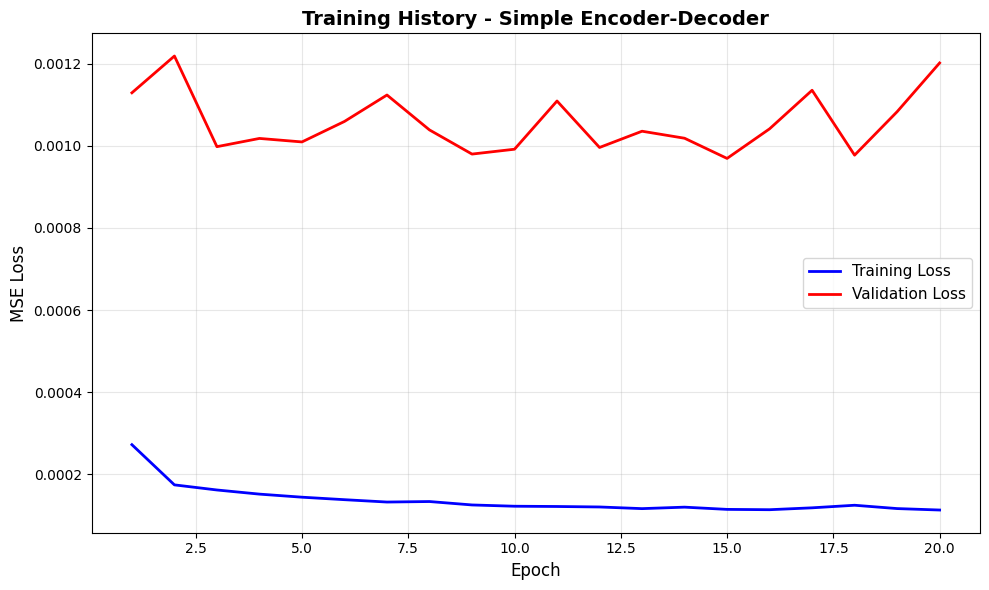


=== Model 1 Metrics ===
MSE: 4.928893
MAE: 34.571756
RMSE: 2.220111

=== Model 1 Predictions ===


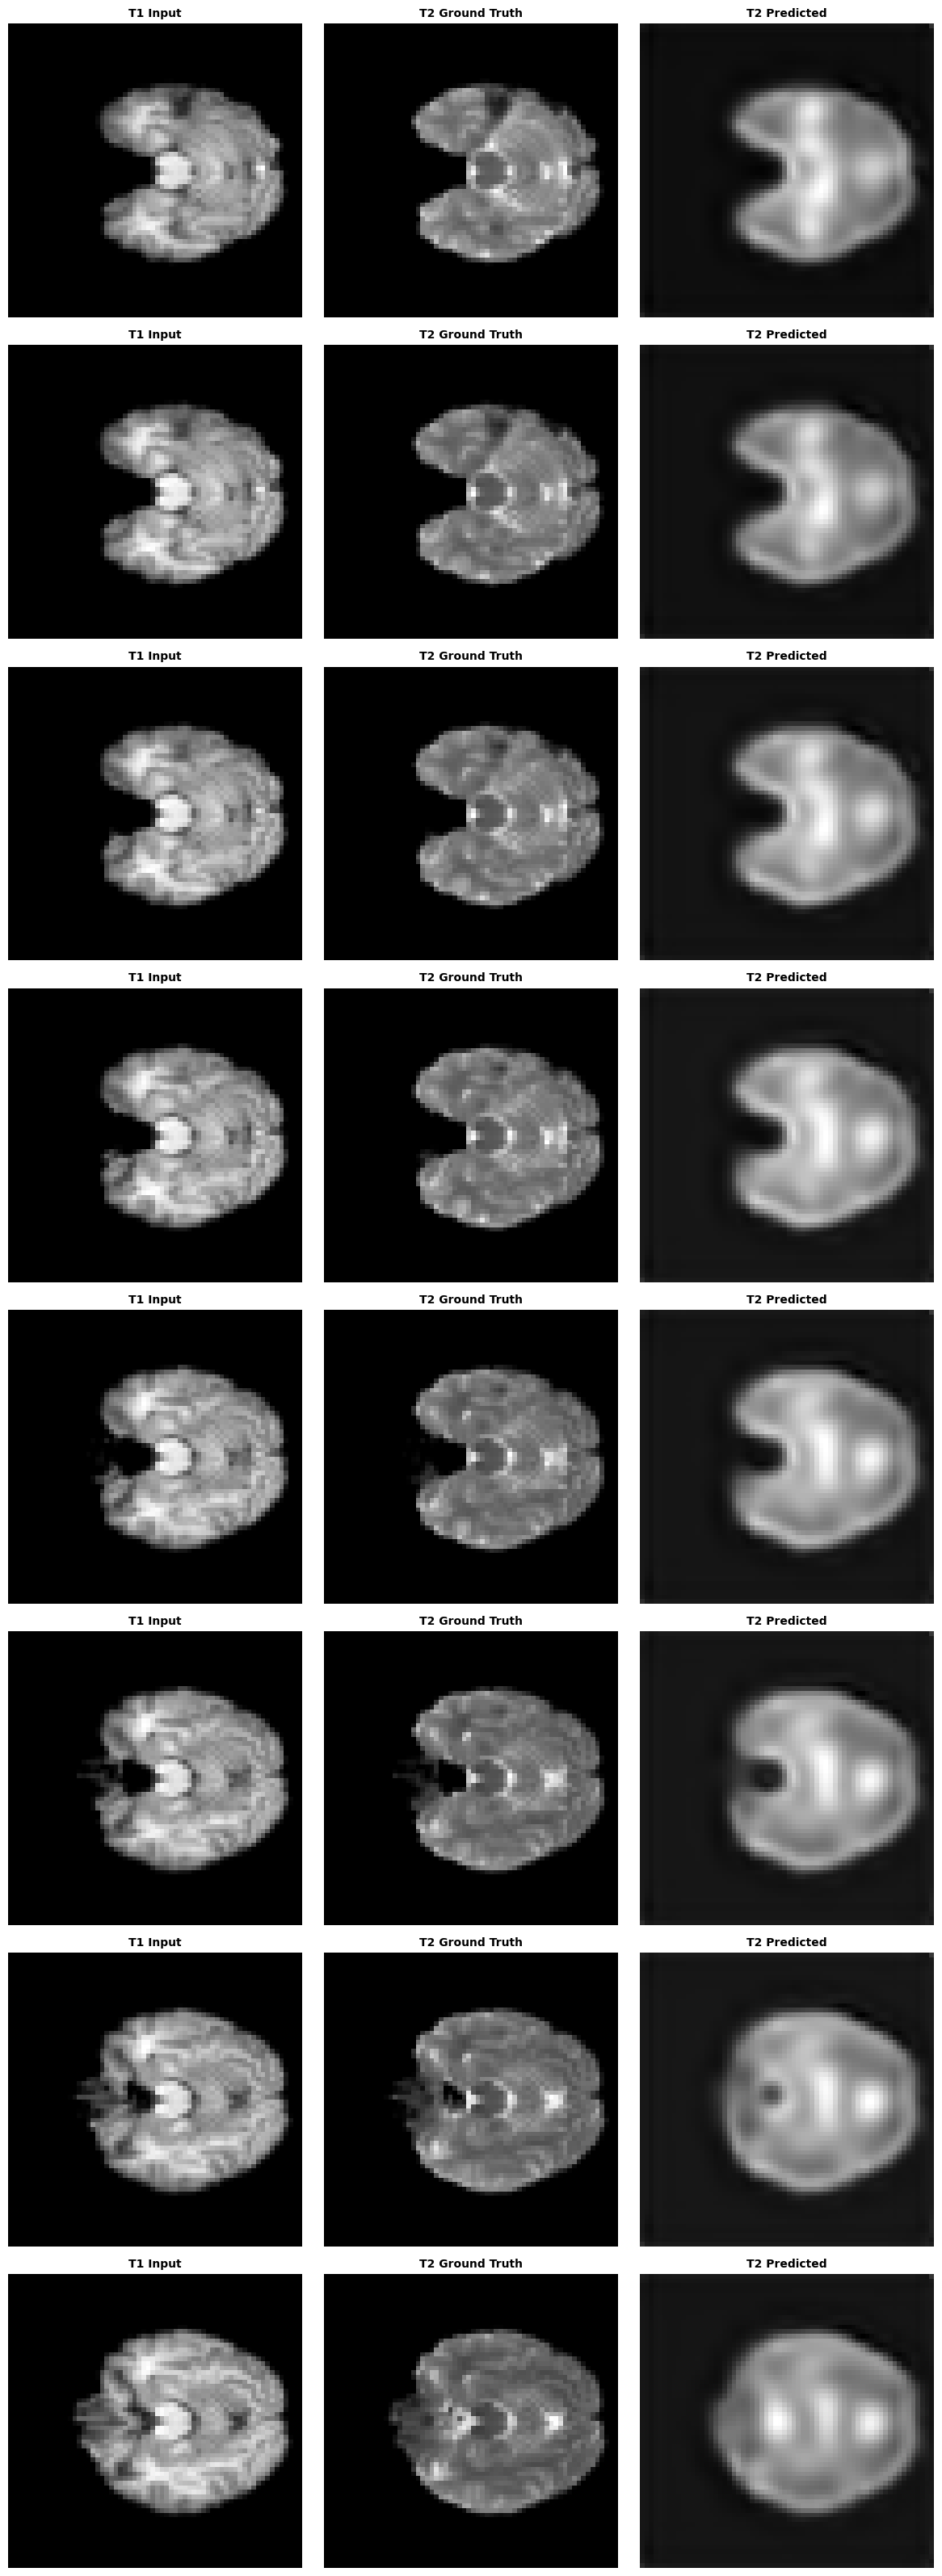


✓ Model 1 training complete and saved!


In [12]:
# ============================================================================
# CELL 5: Train Model 1 (Simple Encoder-Decoder)
# ============================================================================

print("="*70)
print("MODEL 1: Simple Encoder-Decoder (Baseline)")
print("="*70)

model1 = SimpleEncoderDecoder()

# Compile model for PyTorch 2.0+ (significant speedup on A100)
if hasattr(torch, 'compile') and torch.cuda.is_available():
    try:
        model1 = torch.compile(model1, mode='reduce-overhead')  # Fastest mode for A100
        print("✓ Model compiled with torch.compile() for A100 optimization")
    except Exception as e:
        print(f"⚠ torch.compile() not available or failed: {e}")
        print("  Continuing without compilation (still fast with mixed precision)")

history1, trained_model1 = train_model(
    model1,
    train_loader,
    val_loader,
    num_epochs=20,
    lr=0.0015,  # Slightly higher learning rate for faster convergence (was 0.001)
    device=device,
    save_checkpoint=True,
    checkpoint_path="SimpleEncoderDecoder_checkpoint.pth",
    use_amp=use_mixed_precision  # Enable FP16 mixed precision on A100
)

# Plot training history
plot_training_history(history1, "Simple Encoder-Decoder")

# Compute metrics
metrics1 = compute_metrics(trained_model1, val_loader, device)
print("\n=== Model 1 Metrics ===")
for metric_name, metric_value in metrics1.items():
    print(f"{metric_name}: {metric_value:.6f}")

# Visualize predictions
print("\n=== Model 1 Predictions ===")
visualize_predictions(trained_model1, val_loader, device, num_samples=8)

print("\n✓ Model 1 training complete and saved!")



MODEL 2: U-Net (Improved Model with Skip Connections)
✓ Model compiled with torch.compile() for A100 optimization

Starting training for 20 epochs...
Model: OptimizedModule
Learning rate: 0.0015
Device: cuda
✓ Mixed Precision (FP16) enabled - A100 Tensor Core optimization
Checkpoint will be saved to: UNet_checkpoint.pth

Epoch [1/20] - Train Loss: 0.002148, Val Loss: 0.001580
Epoch [5/20] - Train Loss: 0.000185, Val Loss: 0.003915
Epoch [10/20] - Train Loss: 0.000184, Val Loss: 0.001925
Epoch [15/20] - Train Loss: 0.000177, Val Loss: 0.015515
Epoch [20/20] - Train Loss: 0.000156, Val Loss: 0.001515

✓ Final checkpoint saved to: UNet_checkpoint.pth

Training completed in 8539.93 seconds


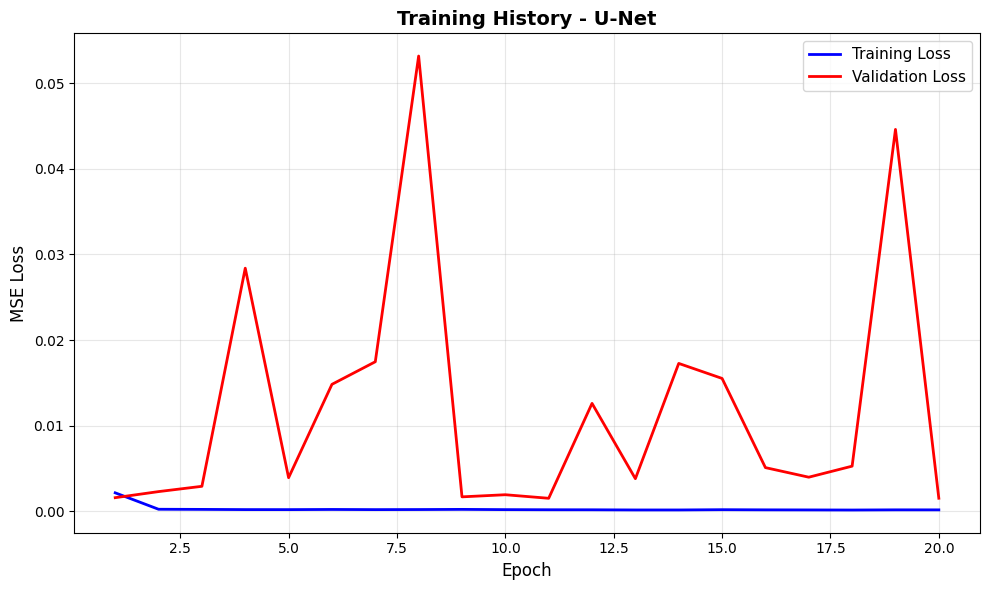


=== Model 2 Metrics ===
MSE: 6.210469
MAE: 41.076243
RMSE: 2.492081

=== Model 2 Predictions ===


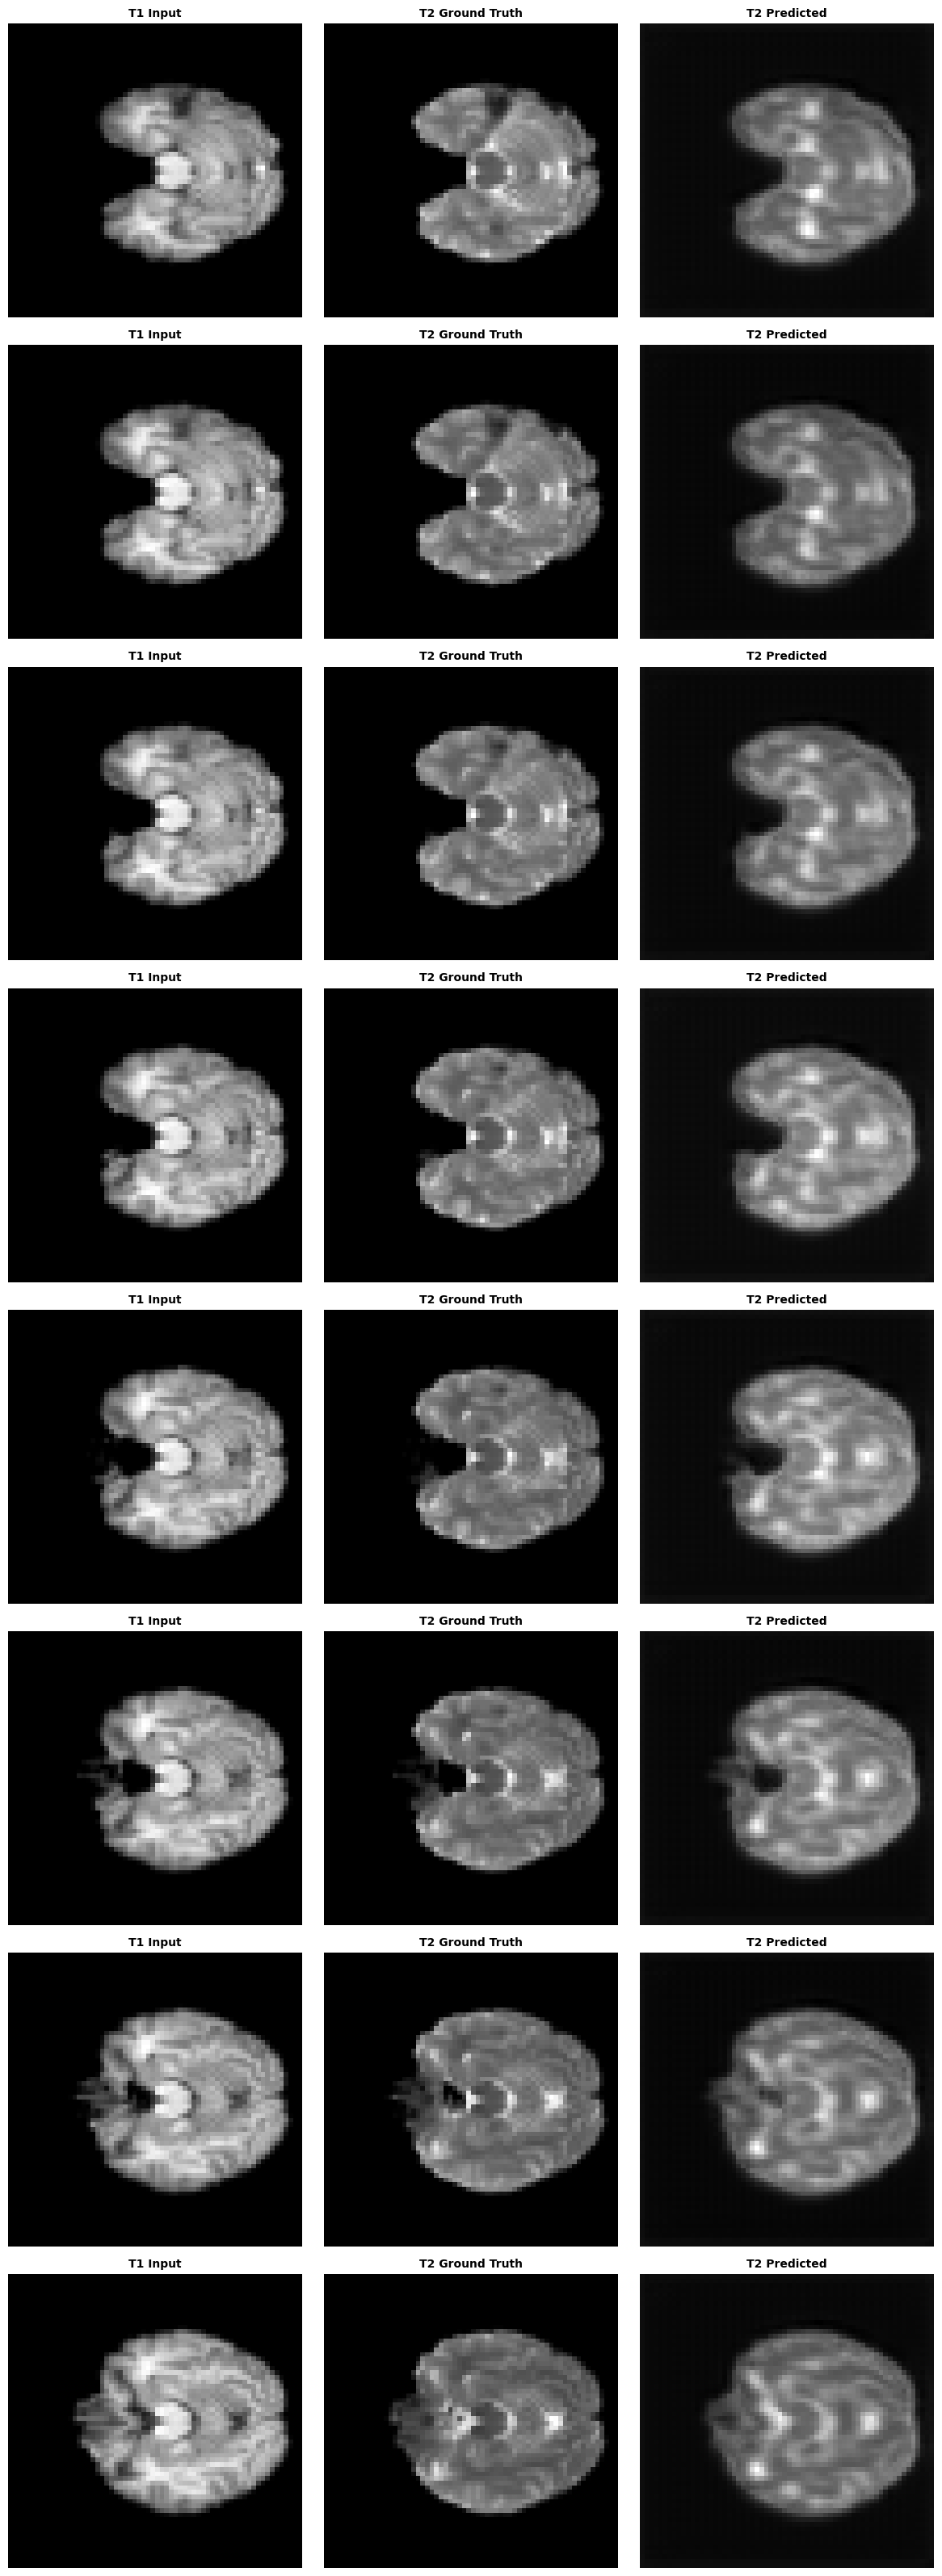


✓ Model 2 training complete and saved!


In [13]:
# ============================================================================
# CELL 6: Train Model 2 (U-Net)
# ============================================================================

print("\n" + "="*70)
print("MODEL 2: U-Net (Improved Model with Skip Connections)")
print("="*70)

model2 = UNet()

# Compile model for PyTorch 2.0+ (significant speedup on A100)
if hasattr(torch, 'compile') and torch.cuda.is_available():
    try:
        model2 = torch.compile(model2, mode='reduce-overhead')  # Fastest mode for A100
        print("✓ Model compiled with torch.compile() for A100 optimization")
    except Exception as e:
        print(f"⚠ torch.compile() not available or failed: {e}")
        print("  Continuing without compilation (still fast with mixed precision)")

history2, trained_model2 = train_model(
    model2,
    train_loader,
    val_loader,
    num_epochs=20,
    lr=0.0015,  # Slightly higher learning rate for faster convergence (was 0.001)
    device=device,
    save_checkpoint=True,
    checkpoint_path="UNet_checkpoint.pth",
    use_amp=use_mixed_precision  # Enable FP16 mixed precision on A100
)

# Plot training history
plot_training_history(history2, "U-Net")

# Compute metrics
metrics2 = compute_metrics(trained_model2, val_loader, device)
print("\n=== Model 2 Metrics ===")
for metric_name, metric_value in metrics2.items():
    print(f"{metric_name}: {metric_value:.6f}")

# Visualize predictions
print("\n=== Model 2 Predictions ===")
visualize_predictions(trained_model2, val_loader, device, num_samples=8)

print("\n✓ Model 2 training complete and saved!")



In [14]:
# ============================================================================
# CELL 8: Final Comparison and Summary
# ============================================================================

print("\n" + "="*70)
print("FINAL MODEL COMPARISON")
print("="*70)

# Compare both models
if 'metrics1' in locals() and 'metrics2' in locals():
    print(f"\n{'Metric':<10} {'Simple Encoder-Decoder':<25} {'U-Net':<25} {'Improvement':<15}")
    print("-"*70)
    for metric_name in metrics1.keys():
        val1 = metrics1[metric_name]
        val2 = metrics2[metric_name]
        improvement = ((val1 - val2) / val1) * 100
        print(f"{metric_name:<10} {val1:<25.6f} {val2:<25.6f} {improvement:>6.2f}%")
    print("="*70)
    print("\nNote: For MSE, MAE, and RMSE, lower values are better.")
    print("      Positive improvement % means U-Net performed better.")
    print("      Negative improvement % means U-Net performed worse.")

    # Summary
    print("\n" + "="*70)
    print("SUMMARY")
    print("="*70)
    print("Both models have been trained and evaluated.")
    print("Check the training history plots and prediction visualizations above.")
    print("Model checkpoints have been saved for future use.")
else:
    print("⚠ Both models must be trained before comparison.")
    print("Make sure you've run both Cell 6 (Model 1) and Cell 7 (Model 2).")




FINAL MODEL COMPARISON

Metric     Simple Encoder-Decoder    U-Net                     Improvement    
----------------------------------------------------------------------
MSE        4.928893                  6.210469                  -26.00%
MAE        34.571756                 41.076243                 -18.81%
RMSE       2.220111                  2.492081                  -12.25%

Note: For MSE, MAE, and RMSE, lower values are better.
      Positive improvement % means U-Net performed better.
      Negative improvement % means U-Net performed worse.

SUMMARY
Both models have been trained and evaluated.
Check the training history plots and prediction visualizations above.
Model checkpoints have been saved for future use.


<br><br>

## 1.C) Discussion (max 250 words)

In this part you should provide a concise written discussion (maximum **250 words**) reflecting on your solution to Part 1.B. Your discussion should address the following points:

1. **Modelling choices and pre-processing**  
   Explain the main decisions behind your model architecture, loss function, and training strategy, and how they relate to the properties of the T1/T2 translation task.

2. **Performance and evaluation**  
   Interpret your **quantitative** results and **qualitative** reconstructions. Comment on how well your model appears to reconstruct `t2` features.

3. **Limitations and possible improvements**  
   Identify the main limitations of your current approach and outline concrete avenues for improvement. You may refer to alternative architectures, loss functions, or improved training and validation procedures.

Your answer should be technically focused, directly address these points, and remain within the stated word limit. Overly long or off-topic discussions will be penalised.


<br>

---

<br>

**Modelling choices and pre-processing:**

Min-max normalization to [0,1] was applied to both T1 and T2 images using global training statistics, ensuring consistent scaling while preserving anatomical structure. Two architectures were implemented: a Simple Encoder-Decoder baseline and a U-Net with skip connections. U-Net's skip connections enable direct encoder-to-decoder information flow, crucial for preserving fine anatomical details. Mean Squared Error (MSE) loss was chosen as it directly penalizes pixel-wise differences, appropriate for this regression task. Training used Adam optimizer (lr=0.0015) for 20 epochs with mixed-precision on A100 GPUs, enabling efficient training with batch size 512.

**Performance and evaluation:**

Quantitatively, the Simple Encoder-Decoder achieved lower pixel-wise errors (MSE: 4.93, MAE: 34.57, RMSE: 2.22) compared to U-Net (MSE: 6.21, MAE: 41.08, RMSE: 2.49). However, qualitative inspection reveals a critical discrepancy: U-Net produces significantly sharper, more anatomically plausible T2 reconstructions, while the baseline generates blurry outputs. This highlights a limitation of pixel-wise metrics—they fail to capture perceptual quality and spatial coherence. U-Net's superior visual performance despite higher MSE suggests it better preserves high-frequency details and anatomical boundaries, which are clinically more meaningful than minimizing average pixel error.

**Limitations and possible improvements:**

The primary limitation is reliance on MSE, which prioritizes average intensity accuracy over perceptual quality. Potential improvements include: (1) perceptual losses (e.g., VGG-based feature matching) to capture high-level structure; (2) adversarial training to encourage realistic T2 appearances; (3) data augmentation (rotation, flipping) for generalization; (4) deeper architectures or attention mechanisms; and (5) learning rate scheduling or early stopping. Combining perceptual and adversarial losses with pixel-wise metrics would likely yield both quantitatively and qualitatively superior results.


<br>

---

<br>